# TODO: Refactor this notebook 

Meso Evaluation - Evaluation of the predictions at the medium level 

For each threshold (mean / average) across images 
DSB AP is the only metric to assess at this level as it allows to get results for all thresholds and all images

In [1]:
import os, json
from pathlib import Path
from functools import reduce
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon as MplPolygon
from matplotlib import rcParams
from shapely.geometry import Polygon
import numpy as np
import matplotlib.patheffects as PathEffects
from matplotlib.patches import Patch

import scienceplots
plt.style.use(['science', 'notebook', 'grid', 'no-latex'])

In [2]:
input_gt_json_path = '../../../../data/annotations_filtered_artifacts/test/COCO_mask/annotations.json'
output_pred_json_path = '../../Global_Outputs/stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts/predicted_annotations.json'

outputs_folder = Path('./../../Global_Outputs')
micro_metric_file = "per_image_threshold_metrics.csv"

In [3]:
with open(input_gt_json_path) as f:
    input_gt_json = json.load(f)

# COCO Evaluation

COCO requires to set parameters of :
* area range
* max number of detections

In [6]:
# Define here the area thresholds for small, medium, and large objects
# Here thresholds are based on 33 and 66 percentiles of bounding box areas

# Compute areas of all bounding boxes
areas = [ann['bbox'][2] * ann['bbox'][3] for ann in input_gt_json['annotations']]

# Calculate thresholds at 33rd and 66th percentiles
q1 = np.percentile(areas, 33)
q2 = np.percentile(areas, 66)

# Define size group function
def size_group(area):
    if area <= q1:
        return 'small'
    elif area <= q2:
        return 'medium'
    else:
        return 'large'

# Count objects in each group
counts = {'small': 0, 'medium': 0, 'large': 0}
for area in areas:
    counts[size_group(area)] += 1

print(f"Thresholds:")
print(f"Small Area<= {q1:.2f}")
print(f"Medium Area> {q1:.2f} and <= {q2:.2f}")
print(f"Large Area> {q2:.2f}")
print("\nNumber of objects in each category:")
for group, count in counts.items():
    print(f"{group.capitalize()}: {count}")

Thresholds:
Small Area<= 120.00
Medium Area> 120.00 and <= 348.00
Large Area> 348.00

Number of objects in each category:
Small: 947
Medium: 920
Large: 959


# Threshold-wise results
* AP
* mean TP, FP, FN

In [4]:
# Functions to highlight maximum values in DataFrame cells for better visualization
def highlight_max(s):
    """Highlight the maximum value in each row with bold red text."""
    is_max = s == s.max()
    return ['font-weight: bold; color: red' if v else '' for v in is_max]

def highlight_max_col(s):
    # s is a Series (a column)
    is_max = s == s.max()
    return ['font-weight: bold; color: red' if v else '' for v in is_max]

Once the area and maxDet are defined

In [6]:
path_output = '../../Global_Outputs'

detectron2_list = [
    'detectron2_trial_100__epochs_300_lr_0.00025_unfreeze_TBC_dataset_annotations_filtered_artifacts',
    'detectron2_trial_1__epochs_1000_lr_0.00025_unfreeze_TBC_dataset_annotations_filtered_artifacts'
]

stardist_list = [
    'stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts',
    'stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts_poly'
]

wormswin_list = [
    'wormswin_FineTune_annotations_filtered_artifacts_cnt_wormswin_csb-1'
]

model_names = stardist_list + detectron2_list + wormswin_list

# SIMPLER NAME TO DISPLAY IN SUMMARY
model_name_map = {
    'stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts': 'STARDIST',
    'stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts_poly': 'STARDIST+poly',
    'detectron2_trial_100__epochs_300_lr_0.00025_unfreeze_TBC_dataset_annotations_filtered_artifacts': 'DETECTRON2-100',
    'detectron2_trial_1__epochs_1000_lr_0.00025_unfreeze_TBC_dataset_annotations_filtered_artifacts': 'DETECTRON2-1k',
    'wormswin_FineTune_annotations_filtered_artifacts_cnt_wormswin_csb-1': 'WORMSWIN',
}

In [7]:
def load_meso_results(exp_name: str) -> pd.DataFrame:
    """
    Loads the threshold-wise AP results for a given experiment.
    
    Args:
        exp_name (str): The folder name of the experiment inside outputs_folder.
        
    Returns:
        pd.DataFrame: DataFrame with columns renamed to include experiment prefix,
                      except for 'IoU_thresh'.
    """
    if not os.path.exists(os.path.join(path_output, exp_name, "ap_results.csv")):
        raise FileNotFoundError(f"Results file for {exp_name} not found in {path_output}")
    csv_file = os.path.join(path_output, exp_name, "ap_results.csv")
    df = pd.read_csv(csv_file)

    # Prefix all columns except IoU_thresh with the experiment name for clarity
    prefix = exp_name
    df_renamed = df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col != 'IoU_thresh'})
    
    return df_renamed

# DSB AP for different thresholds
* Best DSB AP

,IoU_thresh,stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts_average_ap,stardist_2D_versatile_fluo_new_edt_dataset_annotations_filtered_artifacts_poly_average_ap,detectron2_trial_100__epochs_300_lr_0.00025_unfreeze_TBC_dataset_annotations_filtered_artifacts_average_ap,detectron2_trial_1__epochs_1000_lr_0.00025_unfreeze_TBC_dataset_annotations_filtered_artifacts_average_ap,wormswin_FineTune_annotations_filtered_artifacts_cnt_wormswin_csb-1_average_ap
0,0.000000,0.612000,0.632500,0.343000,0.443000,0.335900
1,0.050000,0.567900,0.622700,0.310000,0.409600,0.297000
2,0.100000,0.503400,0.598700,0.273700,0.373100,0.258600
3,0.150000,0.440500,0.566600,0.238500,0.350900,0.223800
4,0.200000,0.376400,0.519700,0.179900,0.320600,0.187700
5,0.250000,0.304800,0.464800,0.124400,0.259800,0.149800
6,0.300000,0.261600,0.398700,0.080100,0.217100,0.113200
7,0.350000,0.197000,0.337400,0.049300,0.166200,0.083000
8,0.400000,0.139900,0.279000,0.033400,0.131400,0.063000
9,0.450000,0.100900,0.219600,0.016200,0.084400,0.049600


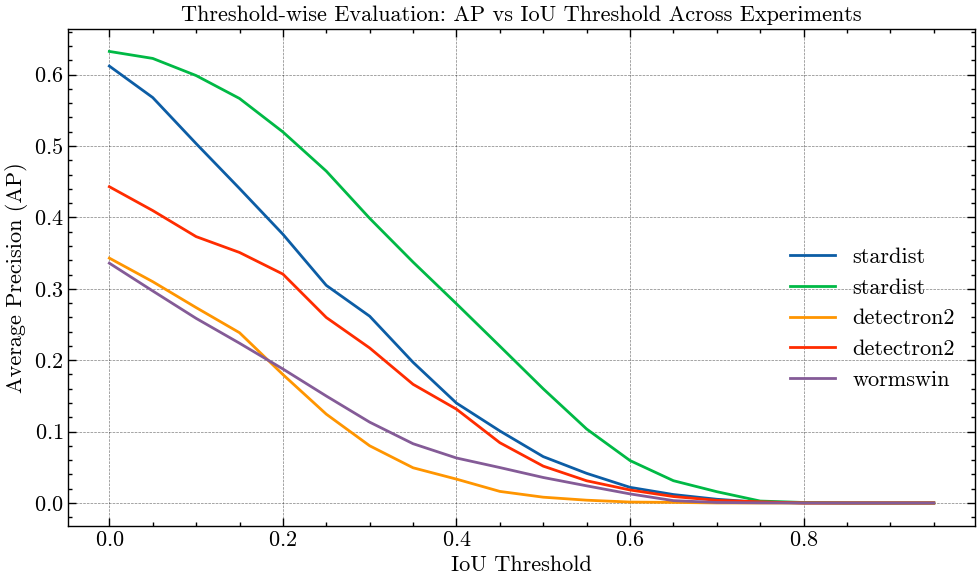

In [8]:
meso_dfs = [load_meso_results(exp) for exp in model_names]
meso_results = reduce(lambda left, right: pd.merge(left, right, on='IoU_thresh', how='outer'), meso_dfs)

styled_df = meso_results.style.apply(highlight_max_col, subset=meso_results.columns[1:], axis=0)
display(styled_df)


plt.style.use(['science', 'notebook', 'grid', 'no-latex'])
plt.figure(figsize=(10, 6))

for col in meso_results.columns:
    if 'ap' in col:
        plt.plot(meso_results['IoU_thresh'], meso_results[col], label=col.split('_')[0])

plt.xlabel("IoU Threshold")
plt.ylabel("Average Precision (AP)")
plt.title("Threshold-wise Evaluation: AP vs IoU Threshold Across Experiments")
plt.grid(True)

# Legend placed below
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.6), ncol=1, frameon=False)

plt.tight_layout()
plt.show()

* TP, FP, FN

In [9]:
# Load the emtrics at pixel level
# CSV stores TP, FP, FN for each IoU threshold and experiment
micro_metric_file = "per_image_threshold_metrics.csv"
outputs_folder = Path('./../../Global_Outputs')
micro_dfs = []

for name in model_names:
    file = outputs_folder / name / micro_metric_file

    if not file.exists():
        print(f"Missing file for {name}")
        continue

    df = pd.read_csv(file)

    if 'threshold' in df.columns and 'IoU_thresh' not in df.columns:
        df.rename(columns={'threshold': 'IoU_thresh'}, inplace=True)

    df['experiment'] = name
    micro_dfs.append(df)

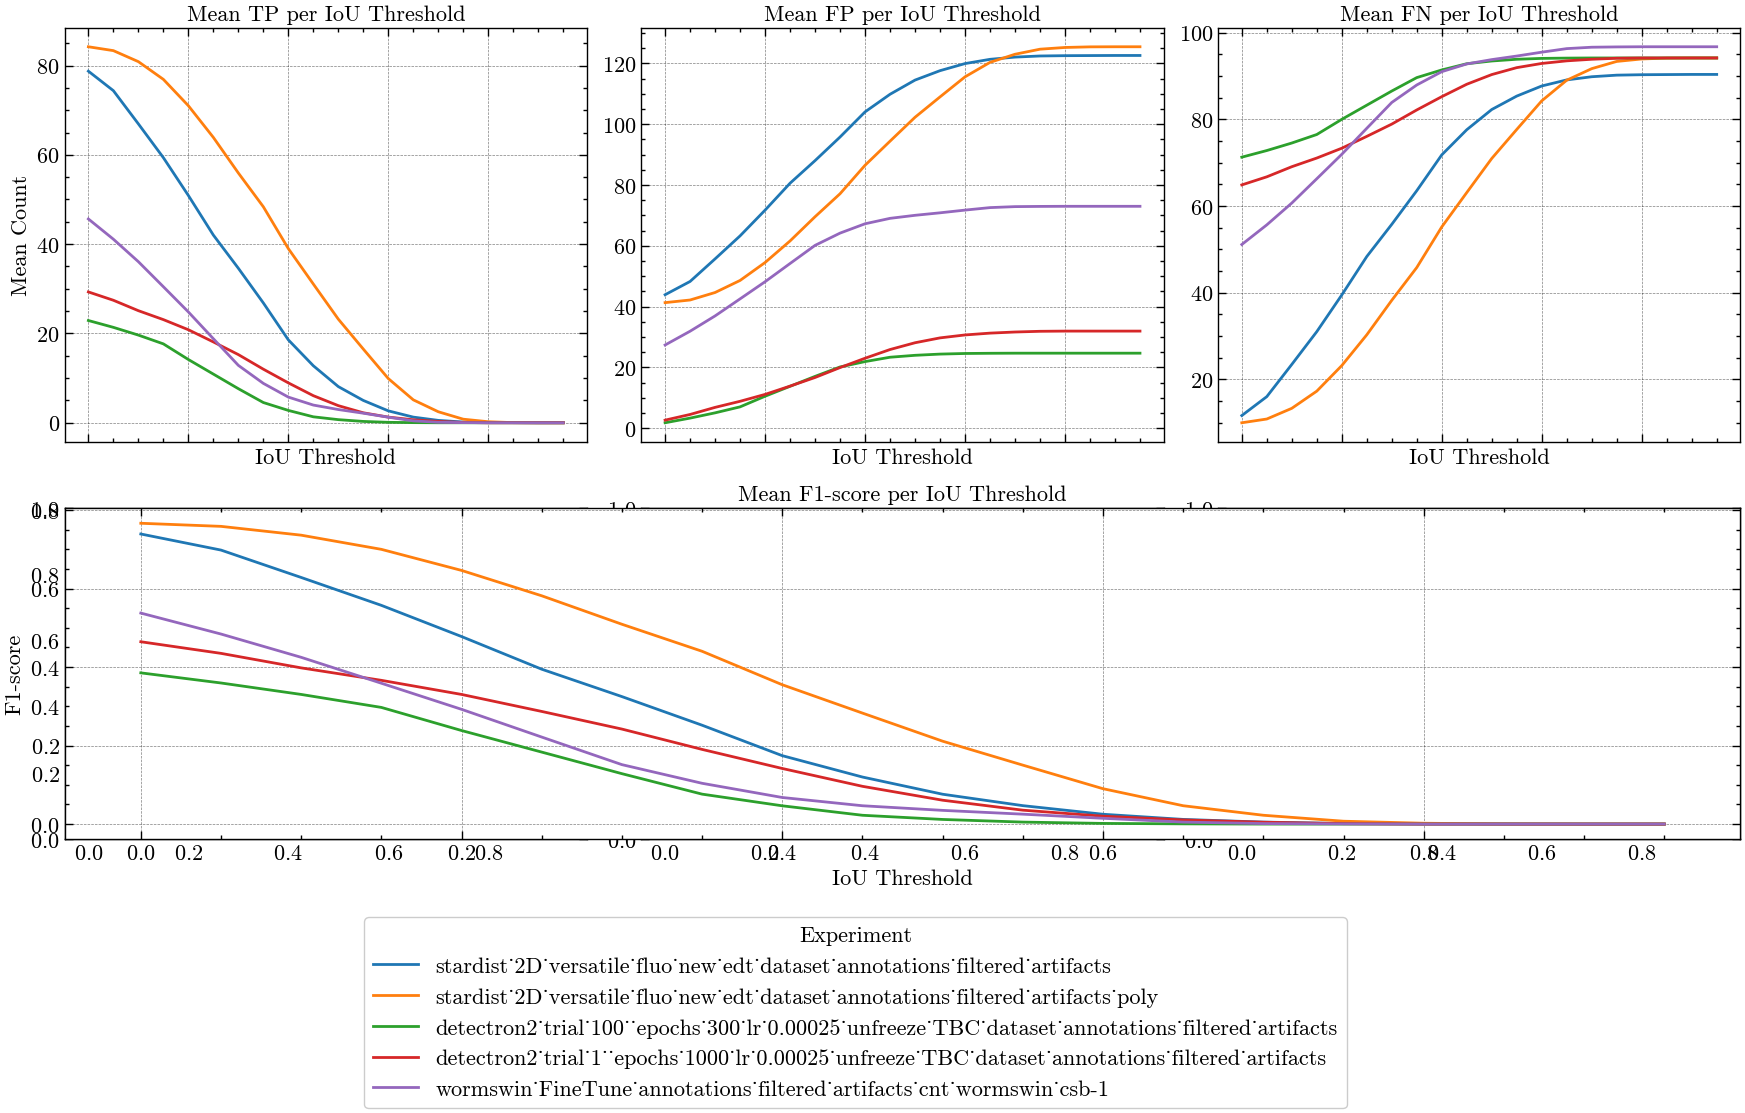

In [10]:
micro_results = pd.concat(micro_dfs, ignore_index=True)
mean_metrics = micro_results.groupby(['experiment', 'IoU_thresh'])[['TP', 'FP', 'FN']].mean().reset_index()
mean_metrics['experiment'] = pd.Categorical(mean_metrics['experiment'], categories=model_names, ordered=True)
mean_metrics = mean_metrics.sort_values(['IoU_thresh', 'experiment'])
mean_metrics['F1'] = 2 * mean_metrics['TP'] / (2 * mean_metrics['TP'] + mean_metrics['FP'] + mean_metrics['FN'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, gridspec_kw={'height_ratios': [1, 0.8]})

metrics = ['TP', 'FP', 'FN']
colors = sns.color_palette('tab10', n_colors=len(model_names))

# Row 1: TP, FP, FN
for i, metric in enumerate(metrics):
    ax = axes[0, i]
    for j, exp in enumerate(mean_metrics['experiment'].cat.categories):
        data = mean_metrics[mean_metrics['experiment'] == exp]
        ax.plot(data['IoU_thresh'], data[metric], label=exp, color=colors[j])
    ax.set_title(f'Mean {metric} per IoU Threshold')
    ax.set_xlabel('IoU Threshold')
    if i == 0:
        ax.set_ylabel('Mean Count')
    ax.grid(True)

# Row 2, column span: F1-score
ax_f1 = plt.subplot2grid((2, 3), (1, 0), colspan=3, fig=fig)
for j, exp in enumerate(mean_metrics['experiment'].cat.categories):
    data = mean_metrics[mean_metrics['experiment'] == exp]
    ax_f1.plot(data['IoU_thresh'], data['F1'], label=exp, color=colors[j])
ax_f1.set_title('Mean F1-score per IoU Threshold')
ax_f1.set_xlabel('IoU Threshold')
ax_f1.set_ylabel('F1-score')
ax_f1.grid(True)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Experiment', loc='lower center', ncol=1, bbox_to_anchor=(0.5, -0.13))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


## COCO

not available for an analysis per threhsold
(anaylsis of the image folder)

# mean DICE

not available for an analysis per threhsold (analysis of each image)